# Week 2 — Solving Systems of Linear Equations

In [20]:
import time

import numpy as np
import matplotlib.pyplot as plt

## Cramer's method — implementation

In [21]:
def compute_determinant(matrix):
    size = matrix.shape[0]
    if size == 1:
        return matrix[0, 0]
    if size == 2:
        return matrix[0, 0] * matrix[1, 1] - matrix[0, 1] * matrix[1, 0]

    total = 0.0
    for column_index in range(size):
        minor_matrix = np.delete(np.delete(matrix, 0, axis=0), column_index, axis=1)
        cofactor_sign = (-1) ** column_index
        total += cofactor_sign * matrix[0, column_index] * compute_determinant(minor_matrix)
    return total


def cramers_rule(matrix, rhs):
    number_of_variables = matrix.shape[0]
    main_determinant = compute_determinant(matrix)
    if abs(main_determinant) < 1e-12:
        raise ValueError("System is singular or not compatible")

    solution = np.zeros(number_of_variables)
    variable_determinants = []
    for variable_index in range(number_of_variables):
        modified_matrix = matrix.astype(float).copy()
        modified_matrix[:, variable_index] = rhs
        variable_determinant = compute_determinant(modified_matrix)
        variable_determinants.append(variable_determinant)
        solution[variable_index] = variable_determinant / main_determinant

    return solution, main_determinant, variable_determinants

## Gaussian elimination method — implementation

In [22]:
def gaussian_elimination(matrix, rhs, verbose=True):
    augmented_matrix = np.hstack([matrix, rhs.reshape(-1, 1)]).astype(float)
    number_of_equations = augmented_matrix.shape[0]

    for pivot_index in range(number_of_equations - 1):
        best_row = pivot_index + np.argmax(np.abs(augmented_matrix[pivot_index:, pivot_index]))
        if best_row != pivot_index:
            augmented_matrix[[pivot_index, best_row]] = augmented_matrix[[best_row, pivot_index]]

        for row_index in range(pivot_index + 1, number_of_equations):
            elimination_factor = augmented_matrix[row_index, pivot_index] / augmented_matrix[pivot_index, pivot_index]
            augmented_matrix[row_index, pivot_index:] -= elimination_factor * augmented_matrix[pivot_index, pivot_index:]

        if verbose:
            print(f"After eliminating column {pivot_index + 1}:\n{np.round(augmented_matrix, 4)}\n")

    solution = np.zeros(number_of_equations)
    for row_index in range(number_of_equations - 1, -1, -1):
        known_terms_sum = np.sum(augmented_matrix[row_index, row_index + 1:number_of_equations] * solution[row_index + 1:])
        solution[row_index] = (augmented_matrix[row_index, -1] - known_terms_sum) / augmented_matrix[row_index, row_index]

    return solution, augmented_matrix

## Gauss-Jordan method — implementation

In [23]:
def gauss_jordan(matrix, rhs, verbose=True):
    augmented_matrix = np.hstack([matrix, rhs.reshape(-1, 1)]).astype(float)
    number_of_rows, number_of_columns = augmented_matrix.shape
    number_of_variables = number_of_columns - 1
    pivot_columns = []
    pivot_row = 0

    for column_index in range(number_of_variables):
        best_row, max_value = None, 1e-9
        for row_index in range(pivot_row, number_of_rows):
            if abs(augmented_matrix[row_index, column_index]) > max_value:
                best_row, max_value = row_index, abs(augmented_matrix[row_index, column_index])
        if best_row is None:
            continue

        augmented_matrix[[pivot_row, best_row]] = augmented_matrix[[best_row, pivot_row]]
        augmented_matrix[pivot_row] /= augmented_matrix[pivot_row, column_index]
        for row_index in range(number_of_rows):
            if row_index != pivot_row:
                augmented_matrix[row_index] -= augmented_matrix[row_index, column_index] * augmented_matrix[pivot_row]

        pivot_columns.append(column_index)
        if verbose:
            print(f"Pivot on x{column_index + 1}:\n{np.round(augmented_matrix, 4)}\n")
        pivot_row += 1
        if pivot_row == number_of_rows:
            break

    return augmented_matrix, pivot_columns

## Jacobi's method — implementation

In [24]:
def jacobi_method(matrix, rhs, guess, max_iter):
    number_of_equations = len(rhs)
    current_solution = np.array(guess, dtype=float)
    iteration_rows = []

    for iteration in range(1, max_iter + 1):
        new_solution = np.zeros(number_of_equations)
        for row_index in range(number_of_equations):
            off_diagonal_sum = sum(
                matrix[row_index, column_index] * current_solution[column_index]
                for column_index in range(number_of_equations) if column_index != row_index
            )
            new_solution[row_index] = (rhs[row_index] - off_diagonal_sum) / matrix[row_index, row_index]
        error = np.max(np.abs(new_solution - current_solution))
        iteration_rows.append((iteration, *new_solution, error))
        current_solution = new_solution

    return current_solution, iteration_rows


def print_iteration_table(iteration_rows):
    print(f"\n{'iter':>4} {'x1':>12} {'x2':>12} {'x3':>12} {'err':>12}")
    for iteration, x1, x2, x3, err in iteration_rows:
        print(f"{iteration:>4} {x1:>12.6f} {x2:>12.6f} {x3:>12.6f} {err:>12.6e}")

## Gauss-Seidel method — implementation

In [25]:
def is_diagonally_dominant(matrix):
    diagonal = np.abs(np.diag(matrix))
    off_diagonal_sum = np.sum(np.abs(matrix), axis=1) - diagonal
    return bool(np.all(diagonal > off_diagonal_sum))


def gauss_seidel(matrix, rhs, guess, max_iter):
    if not is_diagonally_dominant(matrix):
        print("Warning: matrix is not strictly diagonally dominant — convergence is not guaranteed.\n")

    number_of_equations = len(rhs)
    current_solution = np.array(guess, dtype=float)
    iteration_rows = []

    for iteration in range(1, max_iter + 1):
        new_solution = current_solution.copy()
        for row_index in range(number_of_equations):
            updated_terms_sum = sum(
                matrix[row_index, column_index] * new_solution[column_index]
                for column_index in range(row_index)
            )
            previous_terms_sum = sum(
                matrix[row_index, column_index] * current_solution[column_index]
                for column_index in range(row_index + 1, number_of_equations)
            )
            new_solution[row_index] = (rhs[row_index] - updated_terms_sum - previous_terms_sum) / matrix[row_index, row_index]
        error = np.max(np.abs(new_solution - current_solution))
        iteration_rows.append((iteration, *new_solution, error))
        current_solution = new_solution

    return current_solution, iteration_rows

## Relaxation method — implementation

In [26]:
def relaxation_method(matrix, rhs, guess, omega, max_iter):
    if not is_diagonally_dominant(matrix):
        print("Warning: matrix is not strictly diagonally dominant — convergence is not guaranteed.\n")

    number_of_equations = len(rhs)
    current_solution = np.array(guess, dtype=float)
    iteration_rows = []

    for iteration in range(1, max_iter + 1):
        new_solution = current_solution.copy()
        for row_index in range(number_of_equations):
            updated_terms_sum = sum(
                matrix[row_index, column_index] * new_solution[column_index]
                for column_index in range(row_index)
            )
            previous_terms_sum = sum(
                matrix[row_index, column_index] * current_solution[column_index]
                for column_index in range(row_index + 1, number_of_equations)
            )
            gauss_seidel_update = (rhs[row_index] - updated_terms_sum - previous_terms_sum) / matrix[row_index, row_index]
            new_solution[row_index] = (1 - omega) * current_solution[row_index] + omega * gauss_seidel_update
        error = np.max(np.abs(new_solution - current_solution))
        iteration_rows.append((iteration, *new_solution, error))
        current_solution = new_solution

    return current_solution, iteration_rows

## Task 1 — Cramer's method

$$
\begin{cases}
3x - 2y = 5 \\
x + 4y = 11
\end{cases}
$$

In [27]:
matrix = np.array([
    [3, -2],
    [1, 4],
], dtype=float)
rhs = np.array([5, 11], dtype=float)

solution, main_determinant, variable_determinants = cramers_rule(matrix, rhs)

print(f"D  = {main_determinant}")
print(f"Dx = {variable_determinants[0]}")
print(f"Dy = {variable_determinants[1]}")
print(f"\nx = {solution[0]}, y = {solution[1]}")

D  = 14.0
Dx = 42.0
Dy = 28.0

x = 3.0, y = 2.0


## Task 2 — Gaussian elimination method

$$
\left[
\begin{array}{cccc|c}
6.5 & 2.2 & 3.0 & 2.8 & 1.6 \\
4.0 & 3.2 & 1.2 & 4.3 & 4.0 \\
3.2 & 3.3 & 4.0 & 2.0 & 4.5 \\
4.6 & 3.4 & 1.1 & 3.8 & 3.2
\end{array}
\right]
$$

In [28]:
matrix = np.array([
    [6.5, 2.2, 3.0, 2.8],
    [4.0, 3.2, 1.2, 4.3],
    [3.2, 3.3, 4.0, 2.0],
    [4.6, 3.4, 1.1, 3.8],
])
rhs = np.array([1.6, 4.0, 4.5, 3.2])

solution, upper_triangular_matrix = gaussian_elimination(matrix, rhs)

print(f"Upper triangular form:\n{np.round(upper_triangular_matrix, 4)}\n")
print(f"x1 = {solution[0]:.4f}")
print(f"x2 = {solution[1]:.4f}")
print(f"x3 = {solution[2]:.4f}")
print(f"x4 = {solution[3]:.4f}")

After eliminating column 1:
[[ 6.5     2.2     3.      2.8     1.6   ]
 [ 0.      1.8462 -0.6462  2.5769  3.0154]
 [ 0.      2.2169  2.5231  0.6215  3.7123]
 [ 0.      1.8431 -1.0231  1.8185  2.0677]]

After eliminating column 2:
[[ 6.5     2.2     3.      2.8     1.6   ]
 [ 0.      2.2169  2.5231  0.6215  3.7123]
 [ 0.      0.     -2.7473  2.0593 -0.0761]
 [ 0.     -0.     -3.1207  1.3017 -1.0186]]

After eliminating column 3:
[[ 6.5     2.2     3.      2.8     1.6   ]
 [ 0.      2.2169  2.5231  0.6215  3.7123]
 [ 0.     -0.     -3.1207  1.3017 -1.0186]
 [ 0.      0.      0.      0.9134  0.8207]]

Upper triangular form:
[[ 6.5     2.2     3.      2.8     1.6   ]
 [ 0.      2.2169  2.5231  0.6215  3.7123]
 [ 0.     -0.     -3.1207  1.3017 -1.0186]
 [ 0.      0.      0.      0.9134  0.8207]]

x1 = -0.6759
x2 = 0.6246
x3 = 0.7012
x4 = 0.8985


## Task 3 — Gauss-Jordan method

$$
\begin{cases}
2x_1 + 2x_2 - x_3 + x_5 = 0 \\
-x_1 - x_2 + 2x_3 - 3x_4 + x_5 = 0 \\
x_1 + x_2 - 2x_3 - x_5 = 0 \\
x_3 + x_4 + x_5 = 0
\end{cases}
$$

In [29]:
matrix = np.array([
    [2, 2, -1, 0, 1],
    [-1, -1, 2, -3, 1],
    [1, 1, -2, 0, -1],
    [0, 0, 1, 1, 1],
])
rhs = np.zeros(4)

reduced_matrix, pivot_columns = gauss_jordan(matrix, rhs)

number_of_variables = matrix.shape[1]
free_columns = [column_index for column_index in range(number_of_variables) if column_index not in pivot_columns]
print("Reduced row echelon form:\n", np.round(reduced_matrix, 4))
print("\nPivot variables:", [f"x{column_index + 1}" for column_index in pivot_columns])
print("Free variables:  ", [f"x{column_index + 1}" for column_index in free_columns])
for row_index, column_index in enumerate(pivot_columns):
    terms = " ".join(
        f"- {reduced_matrix[row_index, free_column]:+.0f}*x{free_column + 1}"
        for free_column in free_columns if reduced_matrix[row_index, free_column] != 0
    )
    print(f"x{column_index + 1} = {reduced_matrix[row_index, -1]:.0f} {terms}")

Pivot on x1:
[[ 1.   1.  -0.5  0.   0.5  0. ]
 [ 0.   0.   1.5 -3.   1.5  0. ]
 [ 0.   0.  -1.5  0.  -1.5  0. ]
 [ 0.   0.   1.   1.   1.   0. ]]

Pivot on x3:
[[ 1.  1.  0. -1.  1.  0.]
 [ 0.  0.  1. -2.  1.  0.]
 [ 0.  0.  0. -3.  0.  0.]
 [ 0.  0.  0.  3.  0.  0.]]

Pivot on x4:
[[ 1.  1.  0.  0.  1.  0.]
 [ 0.  0.  1.  0.  1.  0.]
 [-0. -0. -0.  1. -0. -0.]
 [ 0.  0.  0.  0.  0.  0.]]

Reduced row echelon form:
 [[ 1.  1.  0.  0.  1.  0.]
 [ 0.  0.  1.  0.  1.  0.]
 [-0. -0. -0.  1. -0. -0.]
 [ 0.  0.  0.  0.  0.  0.]]

Pivot variables: ['x1', 'x3', 'x4']
Free variables:   ['x2', 'x5']
x1 = 0 - +1*x2 - +1*x5
x3 = 0 - +1*x5
x4 = -0 


## Task 4 — Jacobi's method

$$
\begin{cases}
4x + y + z = 7 \\
x + 5y + 2z = 10 \\
x + 2y + 6z = 14
\end{cases}
$$

3 iterations starting from $(0, 0, 0)$.

In [30]:
matrix = np.array([
    [4, 1, 1],
    [1, 5, 2],
    [1, 2, 6],
])
rhs = np.array([7, 10, 14])
guess = [0, 0, 0]

solution, iteration_rows = jacobi_method(matrix, rhs, guess, max_iter=3)
print_iteration_table(iteration_rows)
print(f"\nApproximate solution after 3 iterations: {np.round(solution, 4)}")


iter           x1           x2           x3          err
   1     1.750000     2.000000     2.333333 2.333333e+00
   2     0.666667     0.716667     1.375000 1.283333e+00
   3     1.227083     1.316667     1.983333 6.083333e-01

Approximate solution after 3 iterations: [1.2271 1.3167 1.9833]


## Task 5 — Gauss-Seidel method

$$
\begin{cases}
4x + y + z = 7 \\
x + 5y + 2z = 10 \\
x + 2y + 6z = 14
\end{cases}
$$

3 iterations starting from $(0, 0, 0)$, compared against the Jacobi result from Task 4.

In [31]:
matrix = np.array([
    [4, 1, 1],
    [1, 5, 2],
    [1, 2, 6],
])
rhs = np.array([7, 10, 14])
guess = [0, 0, 0]

print(f"Diagonally dominant: {is_diagonally_dominant(matrix)}")
for row_index in range(matrix.shape[0]):
    diagonal = abs(matrix[row_index, row_index])
    off_diagonal_sum = sum(
        abs(matrix[row_index, column_index])
        for column_index in range(matrix.shape[1]) if column_index != row_index
    )
    comparison_sign = ">" if diagonal > off_diagonal_sum else "<="
    print(f"  row {row_index + 1}: |a_{row_index + 1}{row_index + 1}| = {diagonal} {comparison_sign} sum of others = {off_diagonal_sum}")

solution, iteration_rows = gauss_seidel(matrix, rhs, guess, max_iter=3)
print_iteration_table(iteration_rows)
print(f"\nApproximate solution after 3 iterations: {np.round(solution, 4)}")

Diagonally dominant: True
  row 1: |a_11| = 4 > sum of others = 2
  row 2: |a_22| = 5 > sum of others = 3
  row 3: |a_33| = 6 > sum of others = 3

iter           x1           x2           x3          err
   1     1.750000     1.650000     1.491667 1.750000e+00
   2     0.964583     1.210417     1.769097 7.854167e-01
   3     1.005122     1.091337     1.802034 1.190799e-01

Approximate solution after 3 iterations: [1.0051 1.0913 1.802 ]


## Task 6 — Relaxation method

Same system as Tasks 4–5:

$$
\begin{cases}
4x + y + z = 7 \\
x + 5y + 2z = 10 \\
x + 2y + 6z = 14
\end{cases}
$$

3 iterations starting from $(0, 0, 0)$, relaxation factor $\omega = 1.1$.

In [32]:
matrix = np.array([
    [4, 1, 1],
    [1, 5, 2],
    [1, 2, 6],
])
rhs = np.array([7, 10, 14])
guess = [0, 0, 0]
omega = 1.1

solution, iteration_rows = relaxation_method(matrix, rhs, guess, omega, max_iter=3)
print_iteration_table(iteration_rows)
print(f"\nApproximate solution after 3 iterations: {np.round(solution, 4)}")


iter           x1           x2           x3          err
   1     1.925000     1.776500     1.562367 1.925000e+00
   2     0.814312     1.155760     1.837361 1.110688e+00
   3     1.020461     1.051484     1.810302 2.061489e-01

Approximate solution after 3 iterations: [1.0205 1.0515 1.8103]


## Method Comparison

Run Jacobi (Task 4), Gauss-Seidel (Task 5) and Relaxation (Task 6) on the same system, using the Gauss-Jordan solution as the exact reference, and compare convergence speed and runtime.

iter     Jacobi error   Gauss-Seidel error   Relaxation error
   1     9.278351e-01         7.190722e-01       8.940722e-01
   2     4.291237e-01         1.382517e-01       2.166162e-01
   3     2.445017e-01         2.580631e-02       2.068105e-02
   4     1.141932e-01         4.270572e-03       5.034971e-03
   5     6.686283e-02         4.595974e-04       5.203550e-04
   6     3.310592e-02         2.457326e-05       1.265046e-04
   7     1.874130e-02         4.997854e-06       1.315537e-05
   8     9.677593e-03         9.388310e-07       3.149101e-06
   9     5.320324e-03         1.532477e-07       3.310179e-07
  10     2.802169e-03         1.627941e-08       7.813745e-08

Exact (Gauss-Jordan) solution: [1.030928 1.072165 1.804124]
Jacobi runtime:        0.000216 s, iterations to 1e-06: > 10
Gauss-Seidel runtime:  0.000237 s, iterations to 1e-06: 8
Relaxation runtime:    0.000240 s, iterations to 1e-06: 9


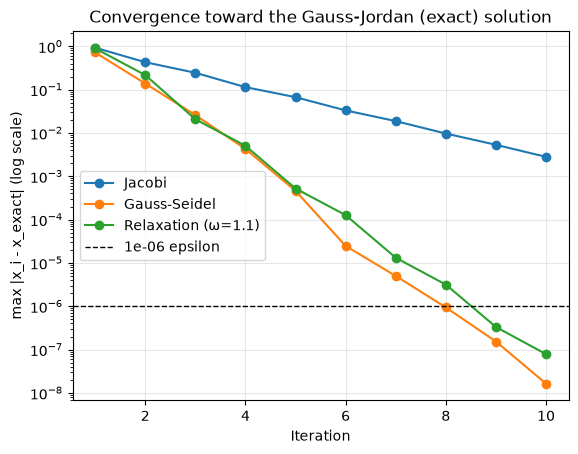

In [33]:
max_iter = 10

reduced_matrix, _ = gauss_jordan(matrix, rhs, verbose=False)
exact_solution = reduced_matrix[:, -1]

start_time = time.perf_counter()
_, jacobi_rows = jacobi_method(matrix, rhs, guess, max_iter)
jacobi_runtime = time.perf_counter() - start_time

start_time = time.perf_counter()
_, gauss_seidel_rows = gauss_seidel(matrix, rhs, guess, max_iter)
gauss_seidel_runtime = time.perf_counter() - start_time

start_time = time.perf_counter()
_, relaxation_rows = relaxation_method(matrix, rhs, guess, omega, max_iter)
relaxation_runtime = time.perf_counter() - start_time

jacobi_errors = [np.max(np.abs(np.array(row[1:4]) - exact_solution)) for row in jacobi_rows]
gauss_seidel_errors = [np.max(np.abs(np.array(row[1:4]) - exact_solution)) for row in gauss_seidel_rows]
relaxation_errors = [np.max(np.abs(np.array(row[1:4]) - exact_solution)) for row in relaxation_rows]

print(f"{'iter':>4} {'Jacobi error':>16} {'Gauss-Seidel error':>20} {'Relaxation error':>18}")
for iteration in range(max_iter):
    print(f"{iteration + 1:>4} {jacobi_errors[iteration]:>16.6e} {gauss_seidel_errors[iteration]:>20.6e} {relaxation_errors[iteration]:>18.6e}")

epsilon = 1e-6
iterations_to_epsilon = lambda errors: next((i for i, e in enumerate(errors, 1) if e < epsilon), f"> {max_iter}")

print(f"\nExact (Gauss-Jordan) solution: {np.round(exact_solution, 6)}")
print(f"Jacobi runtime:        {jacobi_runtime:.6f} s, iterations to {epsilon}: {iterations_to_epsilon(jacobi_errors)}")
print(f"Gauss-Seidel runtime:  {gauss_seidel_runtime:.6f} s, iterations to {epsilon}: {iterations_to_epsilon(gauss_seidel_errors)}")
print(f"Relaxation runtime:    {relaxation_runtime:.6f} s, iterations to {epsilon}: {iterations_to_epsilon(relaxation_errors)}")

plt.figure()
plt.semilogy(range(1, max_iter + 1), jacobi_errors, marker="o", label="Jacobi")
plt.semilogy(range(1, max_iter + 1), gauss_seidel_errors, marker="o", label="Gauss-Seidel")
plt.semilogy(range(1, max_iter + 1), relaxation_errors, marker="o", label=f"Relaxation (ω={omega})")
plt.axhline(epsilon, color="black", linewidth=1, linestyle="--", label=f"{epsilon} epsilon")
plt.title("Convergence toward the Gauss-Jordan (exact) solution")
plt.xlabel("Iteration")
plt.ylabel("max |x_i - x_exact| (log scale)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("gauss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

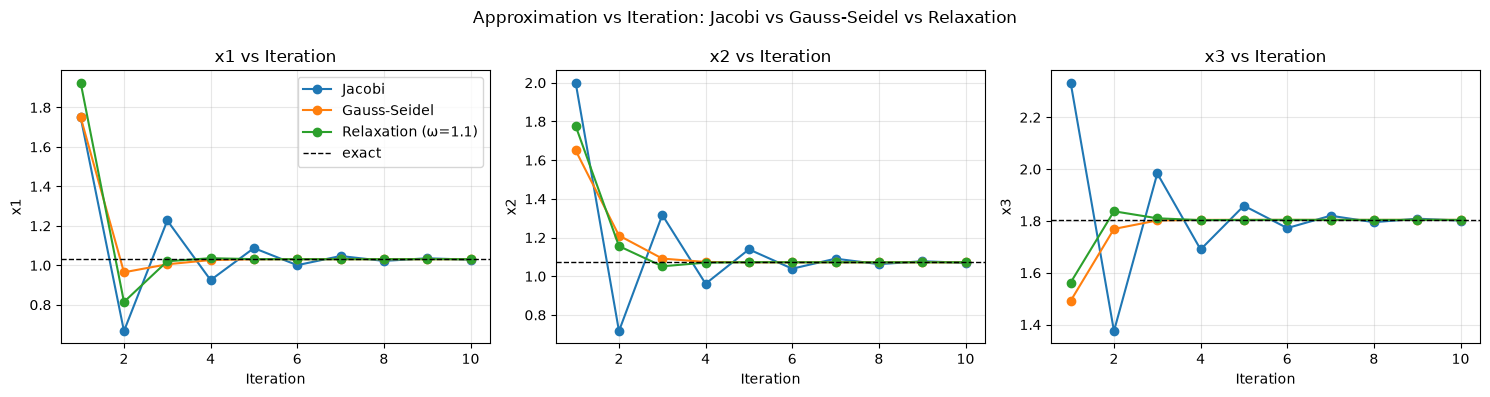

In [34]:
methods = {
    "Jacobi": jacobi_rows,
    "Gauss-Seidel": gauss_seidel_rows,
    f"Relaxation (ω={omega})": relaxation_rows,
}

figure, axes = plt.subplots(1, 3, figsize=(15, 4))
for variable_index, variable_name in enumerate(["x1", "x2", "x3"]):
    axis = axes[variable_index]
    for method_name, rows in methods.items():
        x_values = [row[1 + variable_index] for row in rows]
        axis.plot(range(1, max_iter + 1), x_values, marker="o", label=method_name)
    axis.axhline(exact_solution[variable_index], color="black", linewidth=1, linestyle="--", label="exact")
    axis.set_title(f"{variable_name} vs Iteration")
    axis.set_xlabel("Iteration")
    axis.set_ylabel(variable_name)
    axis.grid(True, alpha=0.3)

axes[0].legend()
figure.suptitle("Approximation vs Iteration: Jacobi vs Gauss-Seidel vs Relaxation")
figure.tight_layout()
figure.savefig("iteration_progress.png", dpi=150, bbox_inches="tight")
plt.show()

## Verification against a reference solver

Ground truth is `np.linalg.solve` (LAPACK) for full-rank square systems (Tasks 1, 2, 4, 5). Task 3 is underdetermined, so instead we check the residual `matrix @ solution - rhs ≈ 0` for a particular solution (free variables set to 1).

In [35]:
def verify_against_reference(matrix, rhs, solution, label):
    reference = np.linalg.solve(matrix, rhs)
    max_difference = np.max(np.abs(solution - reference))
    print(f"{label}")
    print(f"  reference (np.linalg.solve): {np.round(reference, 6)}")
    print(f"  our solution:                {np.round(solution, 6)}")
    print(f"  max abs difference:          {max_difference:.2e}\n")


def verify_residual(matrix, rhs, solution, label):
    max_residual = np.max(np.abs(matrix @ solution - rhs))
    print(f"{label}")
    print(f"  particular solution: {np.round(solution, 6)}")
    print(f"  max residual |matrix @ solution - rhs|: {max_residual:.2e}\n")


# Task 1 — Cramer's rule
matrix = np.array([[3, -2], [1, 4]], dtype=float)
rhs = np.array([5, 11], dtype=float)
solution, _, _ = cramers_rule(matrix, rhs)
verify_against_reference(matrix, rhs, solution, "Task 1 (Cramer's rule)")

# Task 2 — Gaussian elimination
matrix = np.array([
    [6.5, 2.2, 3.0, 2.8],
    [4.0, 3.2, 1.2, 4.3],
    [3.2, 3.3, 4.0, 2.0],
    [4.6, 3.4, 1.1, 3.8],
])
rhs = np.array([1.6, 4.0, 4.5, 3.2])
solution, _ = gaussian_elimination(matrix, rhs, verbose=False)
verify_against_reference(matrix, rhs, solution, "Task 2 (Gaussian elimination)")

# Task 3 — Gauss-Jordan (underdetermined: check residual for free variables = 1)
matrix = np.array([
    [2, 2, -1, 0, 1],
    [-1, -1, 2, -3, 1],
    [1, 1, -2, 0, -1],
    [0, 0, 1, 1, 1],
])
rhs = np.zeros(4)
reduced_matrix, pivot_columns = gauss_jordan(matrix, rhs, verbose=False)
number_of_variables = matrix.shape[1]
free_columns = [column_index for column_index in range(number_of_variables) if column_index not in pivot_columns]
particular_solution = np.zeros(number_of_variables)

for free_column in free_columns:
    particular_solution[free_column] = 1

for row_index, column_index in enumerate(pivot_columns):
    particular_solution[column_index] = reduced_matrix[row_index, -1] - sum(
        reduced_matrix[row_index, free_column] * particular_solution[free_column] for free_column in free_columns
    )

verify_residual(matrix, rhs, particular_solution, "Task 3 (Gauss-Jordan, free variables = 1)")

# Task 4 — Jacobi (3 iterations, approximate)
matrix = np.array([[4, 1, 1], [1, 5, 2], [1, 2, 6]], dtype=float)
rhs = np.array([7, 10, 14], dtype=float)
guess = [0, 0, 0]
solution, _ = jacobi_method(matrix, rhs, guess, max_iter=3)
verify_against_reference(matrix, rhs, solution, "Task 4 (Jacobi, 3 iterations — still converging)")

# Task 5 — Gauss-Seidel (3 iterations, approximate)
solution, _ = gauss_seidel(matrix, rhs, guess, max_iter=3)
verify_against_reference(matrix, rhs, solution, "Task 5 (Gauss-Seidel, 3 iterations — still converging)")

# Task 6 — Relaxation (3 iterations, approximate)
solution, _ = relaxation_method(matrix, rhs, guess, omega=1.1, max_iter=3)
verify_against_reference(matrix, rhs, solution, "Task 6 (Relaxation, 3 iterations — still converging)")

Task 1 (Cramer's rule)
  reference (np.linalg.solve): [3. 2.]
  our solution:                [3. 2.]
  max abs difference:          0.00e+00

Task 2 (Gaussian elimination)
  reference (np.linalg.solve): [-0.675922  0.624601  0.701194  0.898496]
  our solution:                [-0.675922  0.624601  0.701194  0.898496]
  max abs difference:          4.44e-16

Task 3 (Gauss-Jordan, free variables = 1)
  particular solution: [-2.  1. -1. -0.  1.]
  max residual |matrix @ solution - rhs|: 0.00e+00

Task 4 (Jacobi, 3 iterations — still converging)
  reference (np.linalg.solve): [1.030928 1.072165 1.804124]
  our solution:                [1.227083 1.316667 1.983333]
  max abs difference:          2.45e-01

Task 5 (Gauss-Seidel, 3 iterations — still converging)
  reference (np.linalg.solve): [1.030928 1.072165 1.804124]
  our solution:                [1.005122 1.091337 1.802034]
  max abs difference:          2.58e-02

Task 6 (Relaxation, 3 iterations — still converging)
  reference (np.linalg.